In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16,ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [2]:
# Load cifar10

(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
# feature ext with vgg16
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(32,32,3))
for layer in base_model.layers:
  layer.trainable=False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [4]:
x=Flatten()(base_model.output)
x=Dense(512,activation='relu')(x)
output= Dense(10,activation='softmax')(x)
model_feature_extraction=Model(inputs=base_model.input,outputs=output)
model_feature_extraction.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


In [5]:
history=model_feature_extraction.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),batch_size=32)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.5329 - loss: 1.3280 - val_accuracy: 0.5664 - val_loss: 1.2322
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5942 - loss: 1.1548 - val_accuracy: 0.5860 - val_loss: 1.1774
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6211 - loss: 1.0798 - val_accuracy: 0.5990 - val_loss: 1.1423
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6406 - loss: 1.0237 - val_accuracy: 0.6061 - val_loss: 1.1358
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6558 - loss: 0.9739 - val_accuracy: 0.6011 - val_loss: 1.1482
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6709 - loss: 0.9294 - val_accuracy: 0.6190 - val_loss: 1.0997
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6855 - loss: 0.8865 - val_accuracy: 0.6166 - val_loss: 1.1216
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7007 - loss: 

Fine Tuning

In [6]:
base_model=ResNet50(weights='imagenet',include_top=False,input_shape=(32,32,3))
for layer in base_model.layers:
  layer.trainable=False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


new classification layer

In [7]:
x=Flatten()(base_model.output)
x=Dense(512,activation='relu')(x) # Use 'relu' for intermediate layer
final_output= Dense(10,activation='softmax')(x) # Define a new final output layer

model_finetune=Model(inputs=base_model.input, outputs=final_output) # Use the new final_output
model_finetune.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
# unfreeze last 5
for layers in base_model.layers[:5]:
  layers.trainable=True

model_finetune.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])



In [9]:
history_finetune=model_finetune.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),batch_size=32)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.5438 - loss: 1.3319 - val_accuracy: 0.5123 - val_loss: 1.3725
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6164 - loss: 1.0942 - val_accuracy: 0.5525 - val_loss: 1.3069
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6424 - loss: 1.0145 - val_accuracy: 0.4877 - val_loss: 1.5374
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6681 - loss: 0.9441 - val_accuracy: 0.6040 - val_loss: 1.1684
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6896 - loss: 0.8771 - val_accuracy: 0.5470 - val_loss: 1.4251
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7074 - loss: 0.8253 - val_accuracy: 0.5336 - val_loss: 1.4603
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7283 - loss: 0.7644 - val_accuracy: 0.6062 - val_loss: 1.2344
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7503 -

In [10]:
loss_feature_extraction,acc_feature_extraction=model_feature_extraction.evaluate(x_test,y_test)
loss_finetune,acc_finetune=model_finetune.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6175 - loss: 1.1256
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5850 - loss: 1.4725


In [11]:
print(f"Feature Ext. Acc: {acc_feature_extraction*100:.2f}%")
print(f"Finetune Acc: {acc_finetune*100:.2f}%")

Feature Ext. Acc: 61.75%
Finetune Acc: 58.50%


### PyTorch VGG16 Feature Extraction

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [13]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.Resize(224), # VGG16 and ResNet50 typically expect 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize for ImageNet pre-trained models
])

# Load CIFAR-10 training and test datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("CIFAR-10 data loaded and preprocessed for PyTorch.")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:18<00:00, 9.18MB/s]


CIFAR-10 data loaded and preprocessed for PyTorch.
Number of training samples: 50000
Number of test samples: 10000


In [14]:
# Load pre-trained VGG16 model
vgg16_model = models.vgg16(weights='VGG16_Weights.DEFAULT')

# Freeze all parameters in the feature extractor
for param in vgg16_model.features.parameters():
    param.requires_grad = False

# Modify the classifier for CIFAR-10 (10 classes)
num_classes = 10
vgg16_model.classifier = nn.Sequential(
    nn.Linear(vgg16_model.classifier[0].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16_model.to(device)

# Define loss function and optimizer
criterion_vgg16 = nn.CrossEntropyLoss()
optimizer_vgg16 = optim.Adam(vgg16_model.classifier.parameters(), lr=0.001)

print("VGG16 model for feature extraction defined and moved to device.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.4MB/s]


VGG16 model for feature extraction defined and moved to device.


### Saving All Trained Models

### Train PyTorch VGG16 Feature Extraction Model

In [15]:
num_epochs = 10

vgg16_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    vgg16_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_vgg16.zero_grad() # Zero the parameter gradients

        outputs = vgg16_model(inputs)
        loss = criterion_vgg16(outputs, labels)
        loss.backward() # Backpropagation
        optimizer_vgg16.step() # Optimize

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = correct_predictions / total_samples

    vgg16_history['train_loss'].append(epoch_train_loss)
    vgg16_history['train_acc'].append(epoch_train_acc)

    # Validation phase
    vgg16_model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # No gradient calculation during validation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg16_model(inputs)
            loss = criterion_vgg16(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / total_samples
    epoch_val_acc = correct_predictions / total_samples

    vgg16_history['val_loss'].append(epoch_val_loss)
    vgg16_history['val_acc'].append(epoch_val_acc)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Validation Loss: {epoch_val_loss:.4f}, Validation Acc: {epoch_val_acc:.4f}')

print("VGG16 feature extraction training complete.")

Epoch 1/10, Train Loss: 0.6884, Train Acc: 0.7635, Validation Loss: 0.4900, Validation Acc: 0.8331
Epoch 2/10, Train Loss: 0.4695, Train Acc: 0.8406, Validation Loss: 0.4539, Validation Acc: 0.8441
Epoch 3/10, Train Loss: 0.3894, Train Acc: 0.8690, Validation Loss: 0.4887, Validation Acc: 0.8507
Epoch 4/10, Train Loss: 0.3218, Train Acc: 0.8911, Validation Loss: 0.5074, Validation Acc: 0.8512
Epoch 5/10, Train Loss: 0.2761, Train Acc: 0.9071, Validation Loss: 0.5369, Validation Acc: 0.8557
Epoch 6/10, Train Loss: 0.2459, Train Acc: 0.9172, Validation Loss: 0.6069, Validation Acc: 0.8533
Epoch 7/10, Train Loss: 0.2213, Train Acc: 0.9263, Validation Loss: 0.6043, Validation Acc: 0.8617
Epoch 8/10, Train Loss: 0.2038, Train Acc: 0.9342, Validation Loss: 0.6315, Validation Acc: 0.8569
Epoch 9/10, Train Loss: 0.1939, Train Acc: 0.9374, Validation Loss: 0.6838, Validation Acc: 0.8574
Epoch 10/10, Train Loss: 0.1757, Train Acc: 0.9440, Validation Loss: 0.6814, Validation Acc: 0.8615
VGG16 fea

### Plotting VGG16 Feature Extraction Training History

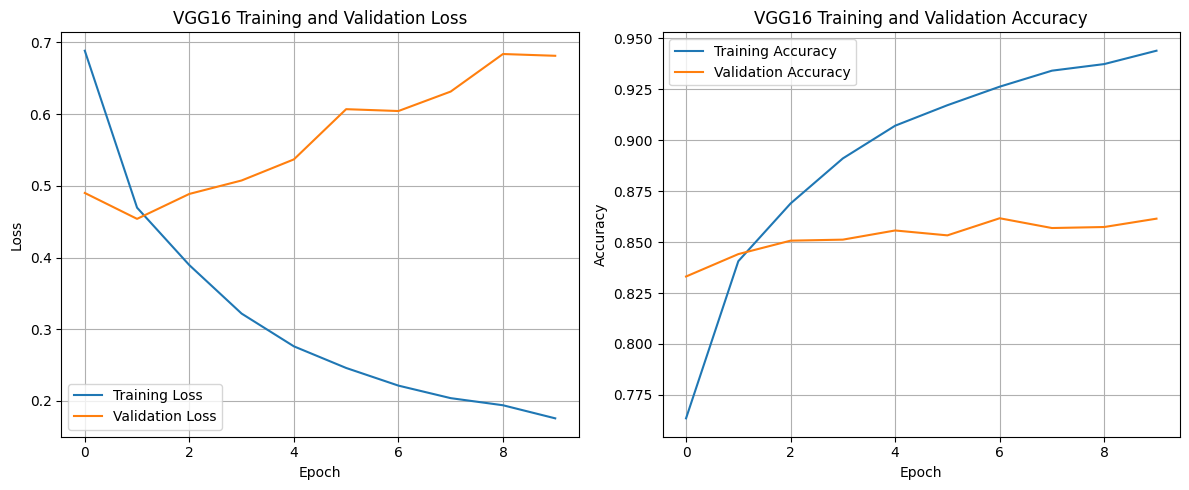

In [16]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(vgg16_history['train_loss'], label='Training Loss')
plt.plot(vgg16_history['val_loss'], label='Validation Loss')
plt.title('VGG16 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(vgg16_history['train_acc'], label='Training Accuracy')
plt.plot(vgg16_history['val_acc'], label='Validation Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### PyTorch ResNet50 Fine-tuning

In [17]:
import torch.nn as nn

# Load pre-trained ResNet50 model
resnet50_model = models.resnet50(weights='ResNet50_Weights.DEFAULT')

# Freeze all parameters initially
for param in resnet50_model.parameters():
    param.requires_grad = False

# Modify the final fully connected layer for CIFAR-10 (10 classes)
num_classes = 10
# User requested 'wsoftma', so we use LogSoftmax and NLLLoss for numerical stability
resnet50_model.fc = nn.Sequential(
    nn.Linear(resnet50_model.fc.in_features, 512), # Added an intermediate dense layer
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes),
    nn.LogSoftmax(dim=1) # Explicit LogSoftmax layer
)

# Unfreeze the last 5 layers/modules explicitly
# 1. The new classification head (resnet50_model.fc)
for param in resnet50_model.fc.parameters():
    param.requires_grad = True

# 2-4. The three Bottleneck modules in layer4
for param in resnet50_model.layer4[2].parameters(): # Last Bottleneck in layer4
    param.requires_grad = True
for param in resnet50_model.layer4[1].parameters(): # Second last Bottleneck in layer4
    param.requires_grad = True
for param in resnet50_model.layer4[0].parameters(): # Third last Bottleneck in layer4
    param.requires_grad = True

# 5. The last Bottleneck module in layer3
for param in resnet50_model.layer3[5].parameters(): # Last Bottleneck in layer3
    param.requires_grad = True

# Move model to device
resnet50_model.to(device)

# Define loss function and optimizer for fine-tuning
# Use NLLLoss since LogSoftmax is explicitly applied in the model's output
criterion_resnet50 = nn.NLLLoss()
# Optimize only the parameters that are set to trainable
optimizer_resnet50 = optim.Adam(filter(lambda p: p.requires_grad, resnet50_model.parameters()), lr=0.00005)

print("ResNet50 model for fine-tuning defined with explicit LogSoftmax, NLLLoss, and specific last 5 modules unfrozen.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


ResNet50 model for fine-tuning defined with explicit LogSoftmax, NLLLoss, and specific last 5 modules unfrozen.


### Train PyTorch ResNet50 Fine-tuning Model

In [18]:
num_epochs_finetune = 5 # Fewer epochs for fine-tuning as it builds on pre-trained weights

resnet50_finetune_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs_finetune):
    resnet50_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_resnet50.zero_grad() # Zero the parameter gradients

        outputs = resnet50_model(inputs)
        loss = criterion_resnet50(outputs, labels)
        loss.backward() # Backpropagation
        optimizer_resnet50.step() # Optimize

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = correct_predictions / total_samples

    resnet50_finetune_history['train_loss'].append(epoch_train_loss)
    resnet50_finetune_history['train_acc'].append(epoch_train_acc)

    # Validation phase
    resnet50_model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # No gradient calculation during validation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50_model(inputs)
            loss = criterion_resnet50(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / total_samples
    epoch_val_acc = correct_predictions / total_samples

    resnet50_finetune_history['val_loss'].append(epoch_val_loss)
    resnet50_finetune_history['val_acc'].append(epoch_val_acc)

    print(f'Epoch {epoch+1}/{num_epochs_finetune}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, Validation Loss: {epoch_val_loss:.4f}, Validation Acc: {epoch_val_acc:.4f}')

print("ResNet50 fine-tuning training complete.")

Epoch 1/5, Train Loss: 0.5947, Train Acc: 0.8103, Validation Loss: 0.3024, Validation Acc: 0.8952
Epoch 2/5, Train Loss: 0.2396, Train Acc: 0.9217, Validation Loss: 0.2789, Validation Acc: 0.9062
Epoch 3/5, Train Loss: 0.1264, Train Acc: 0.9585, Validation Loss: 0.2849, Validation Acc: 0.9099
Epoch 4/5, Train Loss: 0.0676, Train Acc: 0.9779, Validation Loss: 0.3153, Validation Acc: 0.9143
Epoch 5/5, Train Loss: 0.0480, Train Acc: 0.9840, Validation Loss: 0.3341, Validation Acc: 0.9134
ResNet50 fine-tuning training complete.


### Evaluate PyTorch ResNet50 Fine-tuning Model

In [19]:
resnet50_model.eval()
final_test_loss = 0.0
final_test_correct = 0
final_test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet50_model(inputs)
        loss = criterion_resnet50(outputs, labels)

        final_test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        final_test_total += labels.size(0)
        final_test_correct += (predicted == labels).sum().item()

final_test_loss = final_test_loss / final_test_total
final_test_accuracy = final_test_correct / final_test_total

print(f'ResNet50 Fine-tune Test Loss: {final_test_loss:.4f}, Test Accuracy: {final_test_accuracy:.4f}')

ResNet50 Fine-tune Test Loss: 0.3341, Test Accuracy: 0.9134


### Plotting ResNet50 Fine-tuning Training History

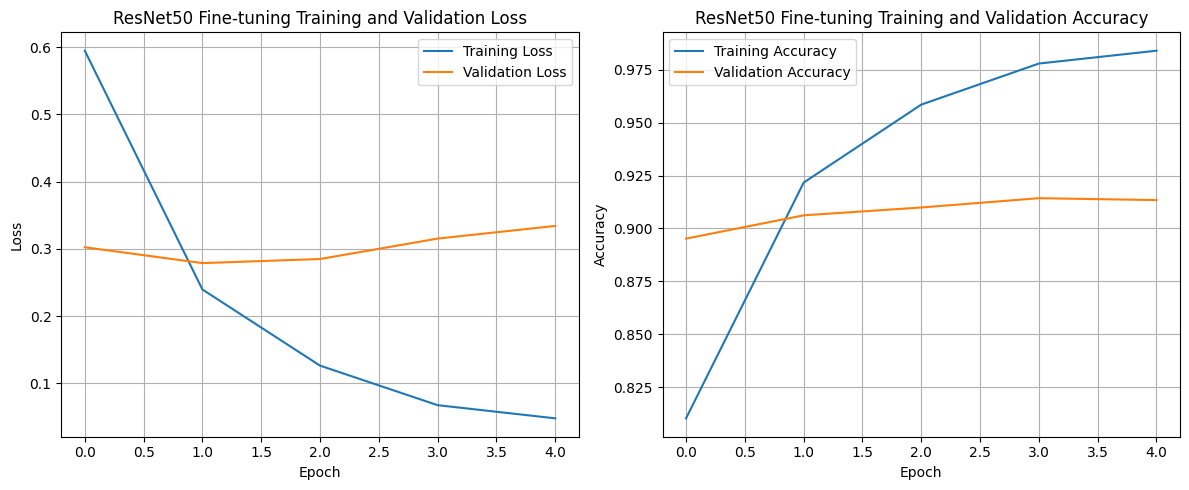

In [20]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(resnet50_finetune_history['train_loss'], label='Training Loss')
plt.plot(resnet50_finetune_history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Fine-tuning Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(resnet50_finetune_history['train_acc'], label='Training Accuracy')
plt.plot(resnet50_finetune_history['val_acc'], label='Validation Accuracy')
plt.title('ResNet50 Fine-tuning Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Save Keras VGG16 Feature Extraction Model
model_feature_extraction.save('keras_vgg16_feature_extraction_model.h5')
print("Keras VGG16 Feature Extraction model saved as 'keras_vgg16_feature_extraction_model.h5'")

# Save Keras ResNet50 Fine-tuning Model
model_finetune.save('keras_resnet50_finetune_model.h5')
print("Keras ResNet50 Fine-tuning model saved as 'keras_resnet50_finetune_model.h5'")

# Save PyTorch VGG16 Feature Extraction Model state_dict
torch.save(vgg16_model.state_dict(), 'pytorch_vgg16_feature_extraction_model_sd.pth')
print("PyTorch VGG16 Feature Extraction model state_dict saved as 'pytorch_vgg16_feature_extraction_model_sd.pth'")

# Save PyTorch ResNet50 Fine-tuning Model state_dict
torch.save(resnet50_model.state_dict(), 'pytorch_resnet50_finetune_model_sd.pth')
print("PyTorch ResNet50 Fine-tuning model state_dict saved as 'pytorch_resnet50_finetune_model_sd.pth'")

Keras VGG16 Feature Extraction model saved as 'keras_vgg16_feature_extraction_model.h5'
Keras ResNet50 Fine-tuning model saved as 'keras_resnet50_finetune_model.h5'
PyTorch VGG16 Feature Extraction model state_dict saved as 'pytorch_vgg16_feature_extraction_model_sd.pth'
PyTorch ResNet50 Fine-tuning model state_dict saved as 'pytorch_resnet50_finetune_model_sd.pth'
